In [1]:
import open3d as o3d

ply_path = "/home/jiahao/ipsm_relighting_v2/outputs/interiorverse/scene_0_bp_3dgs_nv12_v0/point_cloud/iteration_7000/point_cloud.ply"
pcd = o3d.io.read_point_cloud(ply_path)
print(f"点云数量: {len(pcd.points)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
点云数量: 2025340


In [10]:
import open3d as o3d

ply_path = "/home/jiahao/ipsm_relighting_v2/outputs/interiorverse/scene_0_bp_3dgs_nv12_v4/point_cloud/iteration_7000/point_cloud.ply"
pcd = o3d.io.read_point_cloud(ply_path)
print(f"点云数量: {len(pcd.points)}")

点云数量: 1982920


In [1]:
import torch

network_output = torch.rand(3, 4, 4)
gt = torch.rand(3, 4, 4)
mask = torch.ones(4, 4)  # shape: [4, 4]

result = torch.abs((network_output - gt) * mask).sum() / mask.sum()
print(result)

tensor(1.0010)


In [8]:
from PIL import Image
import torch
import numpy as np
from utils.image_utils import psnr
from utils.loss_utils import l1_loss,ssim
path1="/home/jiahao/ipsm_relighting_v3/datasets/interiorverse/scene_0_bp/images/001_albedo.png"
path2="/home/jiahao/ipsm_relighting_v3/outputs/interiorverse/scene_0_bp_neilf_nv12_gsid_mixture_v2/eval/visualize/00003_base_color_linear.png"
path3="/home/jiahao/ipsm_relighting_v3/00000_r3dg.png"
mask_path="/home/jiahao/ipsm_relighting_v3/datasets/interiorverse/scene_0_bp/images/001_mask.png"
def img_to_tensor(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32) / 255.0  # 归一化到0-1
    tensor = torch.from_numpy(arr).permute(2, 0, 1)  # [H,W,C] -> [C,H,W]
    return tensor

# def psnr(img1, img2):
#     mse = torch.mean((img1 - img2) ** 2)
#     if mse == 0:
#         return float('inf')
#     return 20 * torch.log10(torch.tensor(1.0)) - 10 * torch.log10(mse)

tensor1 = img_to_tensor(path1)
tensor2 = img_to_tensor(path2)
tensor3 = img_to_tensor(path3)
mask=img_to_tensor(mask_path)  # 只取单通道作为mask

psnr2 = psnr(tensor2, tensor1,mask).mean().double()
psnr3 = psnr(tensor3, tensor1,mask).mean().double()

print(f"PSNR(path2 vs path1): {psnr2.item():.2f} dB")
print(f"PSNR(path3 vs path1): {psnr3.item():.2f} dB")

ssim2 = ssim(tensor2, tensor1, mask).mean().double()
ssim3 = ssim(tensor3, tensor1, mask).mean().double()

print(f"SSIM(path2 vs path1): {ssim2.item():.4f}")
print(f"SSIM(path3 vs path1): {ssim3.item():.4f}")

PSNR(path2 vs path1): 16.20 dB
PSNR(path3 vs path1): 15.10 dB
SSIM(path2 vs path1): 0.7245
SSIM(path3 vs path1): 0.6818


In [3]:
import numpy as np

relevancy_path = "/home/jiahao/ipsm_relighting_v3/datasets/interiorverse/scene_0_bp/relevancymap/000_im_denoised_relevancy.npy"
relevancy_map = np.load(relevancy_path)
print(relevancy_map.shape)

(360, 480)


In [6]:
import torch

category_features = torch.load("/home/jiahao/ipsm_relighting_v3/datasets/interiorverse/scene_0_bp/category_features.pt")
print(category_features.shape)
print(category_features.device)

torch.Size([15, 512])
cpu


In [12]:
import torch

def region_majority_class(S, M, omega_s=None):
    """
    S: [num_class, H, W] softmax概率
    M: [1, H, W] 区域掩码
    omega_s: [num_class] 类别权重，可选
    返回: 区域主类别索引 int
    """
    # [num_class, H, W] -> [num_class, N]
    mask = M.bool()
    S_masked = S[:, mask[0]]  # [num_class, N]
    print("S_masked shape:", S_masked.shape)
    print("S_masked:", S_masked)
    if omega_s is not None:
        S_masked = S_masked * omega_s[:, None]
    # 每个像素的最大类别
    pixel_cls = S_masked.argmax(dim=0)  # [N]
    print("pixel_cls shape:", pixel_cls.shape)
    print("pixel_cls:", pixel_cls)
    # 区域内最大投票类别
    cls, counts = pixel_cls.unique(return_counts=True)
    print("cls:", cls)
    print("counts:", counts)
    majority_cls = cls[counts.argmax()].item()
    return majority_cls

# 构造测试数据
num_class, H, W = 3, 4, 4
# S: softmax概率，随机生成并归一化
S_raw = torch.rand(num_class, H, W)
S = torch.softmax(S_raw, dim=0)

# M: 区域掩码，选取部分区域为1
M = torch.zeros(1, H, W, dtype=torch.float32)
M[0, 1:3, 1:3] = 1  # 只关注中间2x2区域
print("Softmax概率S:\n", S)
print("区域掩码M:\n", M)
# omega_s: 类别权重
# omega_s = torch.tensor([1.0, 2.0, 0.5])
omega_s = None  # 不使用类别权重

# 调用函数
majority_cls = region_majority_class(S, M, omega_s)
print("区域主类别索引:", majority_cls)

Softmax概率S:
 tensor([[[0.4384, 0.2636, 0.2869, 0.2698],
         [0.3260, 0.3592, 0.3881, 0.2790],
         [0.2864, 0.2845, 0.3683, 0.3959],
         [0.4240, 0.2875, 0.4181, 0.3148]],

        [[0.3888, 0.2913, 0.3617, 0.3499],
         [0.4207, 0.3854, 0.1813, 0.2615],
         [0.2551, 0.3642, 0.2913, 0.3577],
         [0.3011, 0.4788, 0.2382, 0.3265]],

        [[0.1728, 0.4451, 0.3514, 0.3803],
         [0.2533, 0.2555, 0.4305, 0.4595],
         [0.4585, 0.3513, 0.3404, 0.2464],
         [0.2749, 0.2337, 0.3437, 0.3586]]])
区域掩码M:
 tensor([[[0., 0., 0., 0.],
         [0., 1., 1., 0.],
         [0., 1., 1., 0.],
         [0., 0., 0., 0.]]])
S_masked shape: torch.Size([3, 4])
S_masked: tensor([[0.3592, 0.3881, 0.2845, 0.3683],
        [0.3854, 0.1813, 0.3642, 0.2913],
        [0.2555, 0.4305, 0.3513, 0.3404]])
pixel_cls shape: torch.Size([4])
pixel_cls: tensor([1, 2, 1, 0])
cls: tensor([0, 1, 2])
counts: tensor([1, 2, 1])
区域主类别索引: 1


In [14]:
x=torch.zeros(3,4,4)
x[1]=3
x

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[3., 3., 3., 3.],
         [3., 3., 3., 3.],
         [3., 3., 3., 3.],
         [3., 3., 3., 3.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

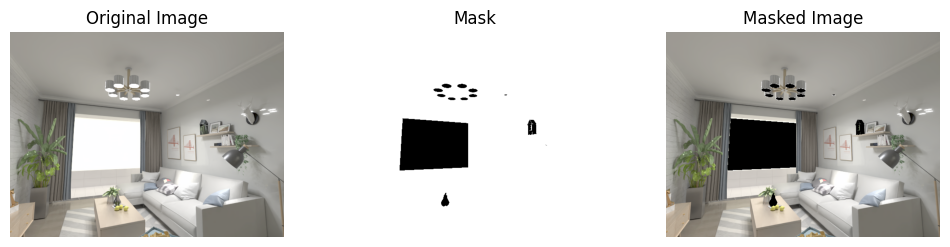

In [36]:
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

# 读取图片
img_path = "/home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/003_im_denoised.png"
mask_path = "/home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/003_mask.png"

img = np.array(Image.open(img_path).convert("RGB"))
mask = np.array(Image.open(mask_path))

# 如果mask是单通道且不是0/1二值，归一化到0-1
if mask.max() > 1:
    mask = mask / 255.0

# 若mask为2D，扩展为3通道
if mask.ndim == 2:
    mask = np.expand_dims(mask, axis=-1)
if mask.shape[-1] == 1:
    mask = np.repeat(mask, 3, axis=-1)

# 应用掩码
masked_img = (img * mask).astype(np.uint8)

# 可视化
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask[...,0], cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Masked Image")
plt.imshow(masked_img)
plt.axis('off')

plt.show()

In [31]:
mask_path = "/home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/000_mask.png"
mask = np.array(Image.open(mask_path))

In [35]:
np.unique(mask)

array([  0, 255], dtype=uint8)

In [28]:
# import OpenEXR
import Imath
import numpy as np
import os
import glob
import imageio.v3 as iio

src_dir = "/home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp"
dst_dir = os.path.join(src_dir, "images")
os.makedirs(dst_dir, exist_ok=True)

exr_files = glob.glob(os.path.join(src_dir, "*_mask.exr"))
for exr_path in exr_files:
    # 读取EXR文件
    exr_data = iio.imread(exr_path)

    # 如果是单通道，直接归一化到0-255；如果多通道，取第一个通道或转为灰度
    if exr_data.ndim == 2:
        img = exr_data
    elif exr_data.ndim == 3:
        img = exr_data[..., 0]
    else:
        raise ValueError(f"Unsupported EXR data shape: {exr_data.shape}")

    # 归一化到0-255
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img_norm = (img - img_min) / (img_max - img_min)
    else:
        img_norm = np.zeros_like(img)
    img_uint8 = (img_norm * 255).astype(np.uint8)

    # 保存为PNG
    base = os.path.basename(exr_path).replace(".exr", ".png")
    out_path = os.path.join(dst_dir, base)
    from PIL import Image
    Image.fromarray(img_uint8).save(out_path)
    print(f"已保存为: {out_path}")


已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/009_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/008_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/015_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/013_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/003_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/005_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/006_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/012_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/010_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/016_mask.png
已保存为: /home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/0

In [7]:
import torch

network_output = torch.rand(3, 4, 4)
gt = torch.rand(3, 4, 4)
mask = torch.ones(1, 4, 4)  # shape: [1, 4, 4]

result = torch.abs((network_output - gt) * mask).sum() / mask.sum()
print(result)

tensor(0.8553)


In [9]:
import random

my_list = [10, 20, 30, 40]
result = random.choice(my_list)
print(result)  # 可能输出 10、20、30 或 40 中的任意一个

20


In [2]:
import torch
torch.manual_seed(42)

In [1]:
import torch

torch.manual_seed(123)
a = torch.rand(2)
b = torch.rand(2)
print(a)  # 总是一样
print(b)  # 总是一样

torch.manual_seed(123)
c = torch.rand(2)
print(c)  # 和a一样

tensor([0.2961, 0.5166])
tensor([0.2517, 0.6886])
tensor([0.2961, 0.5166])


In [2]:
a

tensor([0.2961, 0.5166])

In [4]:
a*-1

tensor([-0.2961, -0.5166])

In [6]:
import torch

# 生成两个int类型的tensor
x = torch.randint(0, 10, (6, 3), dtype=torch.int32)
y = torch.randint(0, 10, (3, 5, 5), dtype=torch.int32)
print("x:", x)
print("y:", y)
# 通过广播机制相减，3维对齐
result = x[:, :, None, None] - y[None, :, :, :]

print("x shape:", x.shape)
print("y shape:", y.shape)
print("result shape:", result.shape)

x: tensor([[1, 9, 8],
        [0, 0, 7],
        [8, 6, 5],
        [1, 9, 0],
        [3, 5, 4],
        [6, 1, 3]], dtype=torch.int32)
y: tensor([[[6, 3, 3, 7, 1],
         [7, 1, 9, 6, 7],
         [9, 9, 5, 6, 6],
         [2, 9, 7, 4, 6],
         [5, 9, 8, 0, 6]],

        [[1, 4, 9, 7, 4],
         [0, 5, 0, 1, 9],
         [5, 1, 8, 5, 4],
         [5, 6, 4, 7, 7],
         [4, 5, 3, 3, 0]],

        [[5, 9, 5, 3, 8],
         [0, 3, 7, 8, 6],
         [3, 4, 8, 8, 5],
         [6, 7, 1, 0, 2],
         [0, 1, 2, 2, 1]]], dtype=torch.int32)
x shape: torch.Size([6, 3])
y shape: torch.Size([3, 5, 5])
result shape: torch.Size([6, 3, 5, 5])


In [9]:
result

tensor([[[[-5, -2, -2, -6,  0],
          [-6,  0, -8, -5, -6],
          [-8, -8, -4, -5, -5],
          [-1, -8, -6, -3, -5],
          [-4, -8, -7,  1, -5]],

         [[ 8,  5,  0,  2,  5],
          [ 9,  4,  9,  8,  0],
          [ 4,  8,  1,  4,  5],
          [ 4,  3,  5,  2,  2],
          [ 5,  4,  6,  6,  9]],

         [[ 3, -1,  3,  5,  0],
          [ 8,  5,  1,  0,  2],
          [ 5,  4,  0,  0,  3],
          [ 2,  1,  7,  8,  6],
          [ 8,  7,  6,  6,  7]]],


        [[[-6, -3, -3, -7, -1],
          [-7, -1, -9, -6, -7],
          [-9, -9, -5, -6, -6],
          [-2, -9, -7, -4, -6],
          [-5, -9, -8,  0, -6]],

         [[-1, -4, -9, -7, -4],
          [ 0, -5,  0, -1, -9],
          [-5, -1, -8, -5, -4],
          [-5, -6, -4, -7, -7],
          [-4, -5, -3, -3,  0]],

         [[ 2, -2,  2,  4, -1],
          [ 7,  4,  0, -1,  1],
          [ 4,  3, -1, -1,  2],
          [ 1,  0,  6,  7,  5],
          [ 7,  6,  5,  5,  6]]],


        [[[ 2,  5,  5,  

In [10]:
import torch

normal = torch.randn(3, 4, 5, requires_grad=True)


In [15]:
a = normal.unsqueeze(0)
b = normal[None]

print(a.shape)  # torch.Size([1, 3, 4, 5])
print(b.shape)  # torch.Size([1, 3, 4, 5])


torch.Size([1, 3, 4, 5])
torch.Size([1, 3, 4, 5])


In [18]:
c=torch.cat([a, b], dim=0)
print(c.shape)  # torch.Size([2, 3, 4, 5])

torch.Size([2, 3, 4, 5])


In [19]:
import numpy as np
c

tensor([[[[-1.0590,  0.0801,  0.3531, -0.1207, -0.9797],
          [-2.1126, -0.2721, -0.3510, -1.6483,  0.1536],
          [-0.1807, -0.1086,  1.1721, -0.4372, -0.4053],
          [ 0.7086, -0.1346,  0.4680, -0.7952, -0.9178]],

         [[-0.0673,  0.2467, -0.9392, -1.0448, -0.4698],
          [ 1.0866, -0.8892,  0.7647, -1.0532,  1.8386],
          [-0.1095, -0.3316, -0.1408, -0.5394, -1.2782],
          [-0.8107,  1.3818, -0.0694, -0.7612,  0.2416]],

         [[-0.4310,  0.0493,  0.8484,  0.4671, -1.8127],
          [ 1.1846,  1.7602,  0.7594,  1.3026, -0.4288],
          [ 0.1164,  1.1851, -1.0565,  1.1510, -0.4669],
          [-0.0411,  1.9089, -0.0500,  1.1308, -0.1539]]],


        [[[-1.0590,  0.0801,  0.3531, -0.1207, -0.9797],
          [-2.1126, -0.2721, -0.3510, -1.6483,  0.1536],
          [-0.1807, -0.1086,  1.1721, -0.4372, -0.4053],
          [ 0.7086, -0.1346,  0.4680, -0.7952, -0.9178]],

         [[-0.0673,  0.2467, -0.9392, -1.0448, -0.4698],
          [ 1.0866, -

In [21]:
c/np.pi

tensor([[[[-0.3371,  0.0255,  0.1124, -0.0384, -0.3118],
          [-0.6725, -0.0866, -0.1117, -0.5247,  0.0489],
          [-0.0575, -0.0346,  0.3731, -0.1392, -0.1290],
          [ 0.2256, -0.0428,  0.1490, -0.2531, -0.2921]],

         [[-0.0214,  0.0785, -0.2989, -0.3326, -0.1496],
          [ 0.3459, -0.2831,  0.2434, -0.3353,  0.5852],
          [-0.0349, -0.1056, -0.0448, -0.1717, -0.4069],
          [-0.2581,  0.4398, -0.0221, -0.2423,  0.0769]],

         [[-0.1372,  0.0157,  0.2701,  0.1487, -0.5770],
          [ 0.3771,  0.5603,  0.2417,  0.4146, -0.1365],
          [ 0.0371,  0.3772, -0.3363,  0.3664, -0.1486],
          [-0.0131,  0.6076, -0.0159,  0.3599, -0.0490]]],


        [[[-0.3371,  0.0255,  0.1124, -0.0384, -0.3118],
          [-0.6725, -0.0866, -0.1117, -0.5247,  0.0489],
          [-0.0575, -0.0346,  0.3731, -0.1392, -0.1290],
          [ 0.2256, -0.0428,  0.1490, -0.2531, -0.2921]],

         [[-0.0214,  0.0785, -0.2989, -0.3326, -0.1496],
          [ 0.3459, -

In [22]:
c.shape

torch.Size([2, 3, 4, 5])

In [23]:
x,y=c.shape[2:]
print(x,y)

4 5
